# Model Comparison: TF-IDF, SVM, and BiLSTM

This notebook compares three emotion-classification baselines on the processed dataset:

- TF-IDF + Logistic Regression
- TF-IDF + Linear SVM
- BiLSTM

It uses the existing train/valid/test splits from `data/processed/` and saves comparison outputs under `reports/model_comparison/`.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
%pip -q install pandas numpy scikit-learn matplotlib seaborn tensorflow

In [2]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Bidirectional, Dense, Dropout, Embedding, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


In [6]:
PROJECT_ROOT = Path('/content/drive/MyDrive/Emotional Aware Chatbot/experiments/goemotions_roberta_full_pipeline')
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
REPORT_DIR = PROJECT_ROOT / 'reports' / 'model_comparison'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(DATA_DIR / 'train.csv')
valid_df = pd.read_csv(DATA_DIR / 'valid.csv')
test_df  = pd.read_csv(DATA_DIR / 'test.csv')

display(train_df.head())
print('Train:', train_df.shape)
print('Valid:', valid_df.shape)
print('Test :', test_df.shape)
print('\nLabels:', sorted(train_df['final_emotion'].unique()))

,text,final_emotion
0,Because [NAME] was playing awful in the first ...,Anger
1,"Nah she's just a dull asari doctor, with a ple...",Anger
2,Was he in your butt?,Neutral
3,Oh nice I have that one,Neutral
4,Wow! I didn't even even know there was a handb...,Sadness


Train: (95078, 2)
Valid: (11885, 2)
Test : (11885, 2)

Labels: ['Anger', 'Fear', 'Joy', 'Love', 'Neutral', 'Sadness']


In [7]:
X_train = train_df['text'].astype(str).tolist()
y_train = train_df['final_emotion'].astype(str).tolist()

X_valid = valid_df['text'].astype(str).tolist()
y_valid = valid_df['final_emotion'].astype(str).tolist()

X_test = test_df['text'].astype(str).tolist()
y_test = test_df['final_emotion'].astype(str).tolist()

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_valid_enc = label_encoder.transform(y_valid)
y_test_enc  = label_encoder.transform(y_test)

label_names = label_encoder.classes_.tolist()
num_classes = len(label_names)
print('Encoded labels:', dict(zip(label_names, range(num_classes))))

Encoded labels: {'Anger': 0, 'Fear': 1, 'Joy': 2, 'Love': 3, 'Neutral': 4, 'Sadness': 5}


## Helper Functions

In [8]:
def compute_metrics(y_true, y_pred, model_name):
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }


def save_confusion_matrix(y_true, y_pred, labels, title, out_path):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    fig.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)


results = []
detailed_reports = {}

## 1. TF-IDF + Logistic Regression

              precision    recall  f1-score   support

       Anger       0.63      0.65      0.64      1981
        Fear       0.95      0.98      0.97      1980
         Joy       0.75      0.66      0.70      1981
        Love       0.73      0.71      0.72      1981
     Neutral       0.49      0.52      0.50      1981
     Sadness       0.79      0.82      0.80      1981

    accuracy                           0.72     11885
   macro avg       0.72      0.72      0.72     11885
weighted avg       0.72      0.72      0.72     11885



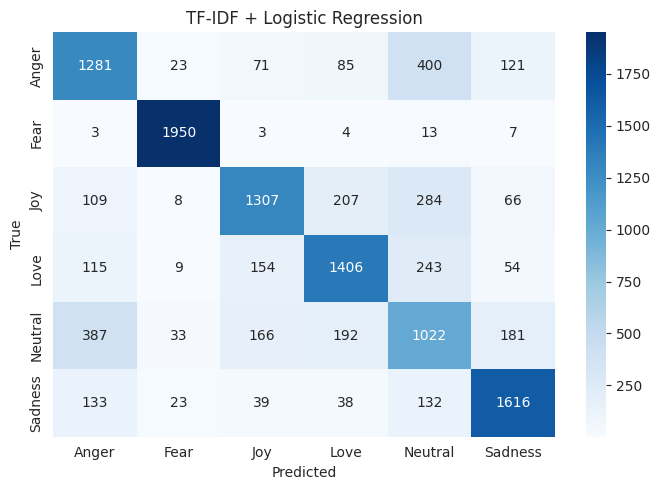

In [9]:
tfidf_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=30000, ngram_range=(1, 2), stop_words='english')),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', n_jobs=None))
])

tfidf_lr.fit(X_train, y_train)
lr_pred = tfidf_lr.predict(X_test)

results.append(compute_metrics(y_test, lr_pred, 'TF-IDF + Logistic Regression'))
detailed_reports['TF-IDF + Logistic Regression'] = classification_report(y_test, lr_pred, output_dict=True, zero_division=0)

print(classification_report(y_test, lr_pred, zero_division=0))
save_confusion_matrix(y_test, lr_pred, label_names, 'TF-IDF + Logistic Regression', REPORT_DIR / 'cm_tfidf_logreg.png')

## 2. TF-IDF + Linear SVM

              precision    recall  f1-score   support

       Anger       0.66      0.70      0.68      1981
        Fear       0.98      0.99      0.98      1980
         Joy       0.75      0.72      0.74      1981
        Love       0.74      0.76      0.75      1981
     Neutral       0.53      0.47      0.50      1981
     Sadness       0.83      0.88      0.86      1981

    accuracy                           0.75     11885
   macro avg       0.75      0.75      0.75     11885
weighted avg       0.75      0.75      0.75     11885



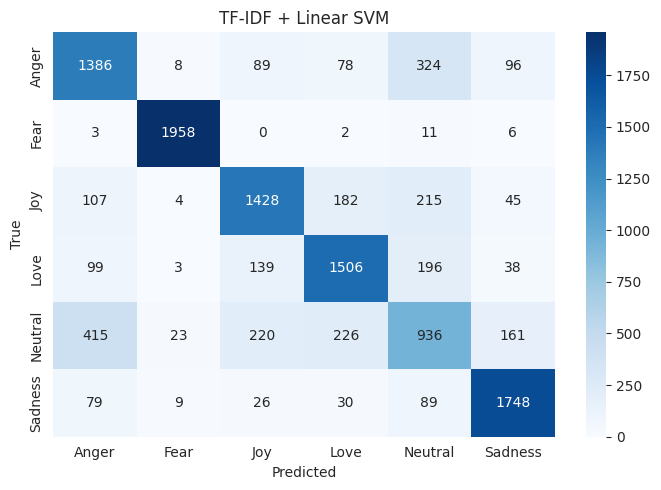

In [10]:
tfidf_svm = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=30000, ngram_range=(1, 2), stop_words='english')),
    ('clf', LinearSVC(class_weight='balanced'))
])

tfidf_svm.fit(X_train, y_train)
svm_pred = tfidf_svm.predict(X_test)

results.append(compute_metrics(y_test, svm_pred, 'TF-IDF + Linear SVM'))
detailed_reports['TF-IDF + Linear SVM'] = classification_report(y_test, svm_pred, output_dict=True, zero_division=0)

print(classification_report(y_test, svm_pred, zero_division=0))
save_confusion_matrix(y_test, svm_pred, label_names, 'TF-IDF + Linear SVM', REPORT_DIR / 'cm_tfidf_svm.png')

## 3. BiLSTM

In [11]:
MAX_WORDS = 30000
MAX_LEN = 120
EMBED_DIM = 128
BATCH_SIZE = 64
EPOCHS = 10

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_valid_seq = tokenizer.texts_to_sequences(X_valid)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_valid_pad = pad_sequences(X_valid_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_valid_cat = to_categorical(y_valid_enc, num_classes=num_classes)
y_test_cat  = to_categorical(y_test_enc, num_classes=num_classes)

bilstm_model = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

bilstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

bilstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = bilstm_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_valid_pad, y_valid_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.5749 - loss: 1.1210 - val_accuracy: 0.7047 - val_loss: 0.8258
Epoch 2/10
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.7536 - loss: 0.7094 - val_accuracy: 0.7481 - val_loss: 0.7281
Epoch 3/10
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.8187 - loss: 0.5367 - val_accuracy: 0.7750 - val_loss: 0.6732
Epoch 4/10
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.8558 - loss: 0.4300 - val_accuracy: 0.7893 - val_loss: 0.6480
Epoch 5/10
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.8818 - loss: 0.3542 - val_accuracy: 0.7966 - val_loss: 0.6746
Epoch 6/10
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.9006 - loss: 0.2971 - val_accuracy: 0.7999 - val_loss: 0.6906


372/372 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
              precision    recall  f1-score   support

       Anger       0.74      0.74      0.74      1981
        Fear       0.96      0.99      0.97      1980
         Joy       0.76      0.76      0.76      1981
        Love       0.80      0.80      0.80      1981
     Neutral       0.61      0.54      0.57      1981
     Sadness       0.85      0.92      0.88      1981

    accuracy                           0.79     11885
   macro avg       0.78      0.79      0.79     11885
weighted avg       0.78      0.79      0.79     11885



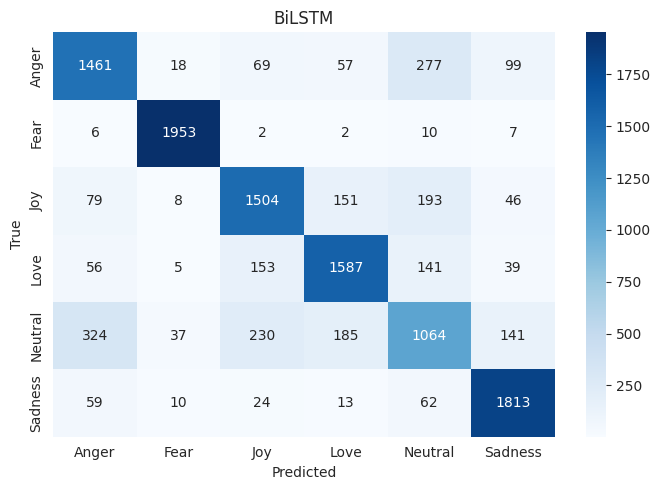

In [13]:
bilstm_probs = bilstm_model.predict(X_test_pad)
bilstm_pred_enc = bilstm_probs.argmax(axis=1)
bilstm_pred = label_encoder.inverse_transform(bilstm_pred_enc)

results.append(compute_metrics(y_test, bilstm_pred, 'BiLSTM'))
detailed_reports['BiLSTM'] = classification_report(y_test, bilstm_pred, output_dict=True, zero_division=0)

print(classification_report(y_test, bilstm_pred, zero_division=0))
save_confusion_matrix(y_test, bilstm_pred, label_names, 'BiLSTM', REPORT_DIR / 'cm_bilstm.png')

## Compare Results

In [14]:
results_df = pd.DataFrame(results).sort_values('f1_weighted', ascending=False).reset_index(drop=True)
results_df

,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,BiLSTM,0.789398,0.784352,0.789398,0.786239
1,TF-IDF + Linear SVM,0.754060,0.749677,0.754060,0.751345
2,TF-IDF + Logistic Regression,0.722087,0.723632,0.722087,0.722191


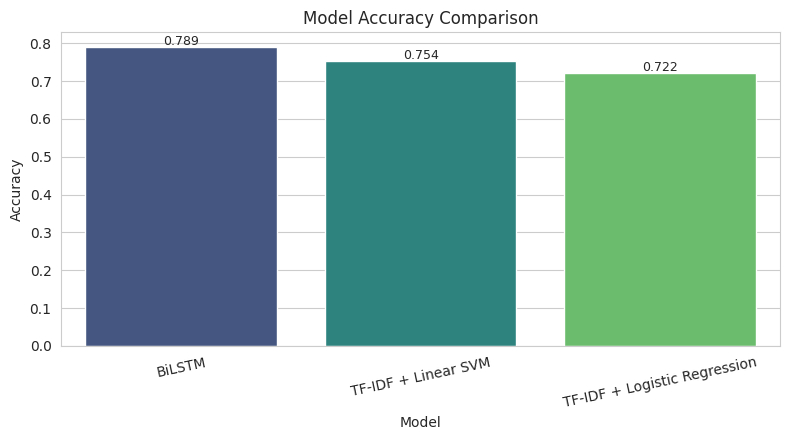

Saved plot to: /content/drive/MyDrive/Emotional Aware Chatbot/experiments/goemotions_roberta_full_pipeline/reports/model_comparison/model_accuracy_comparison.png


In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=results_df, x='model', y='accuracy', palette='viridis', ax=ax)
ax.set_title('Model Accuracy Comparison')
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.tick_params(axis='x', rotation=12)
for i, row in results_df.iterrows():
    ax.text(i, row['accuracy'] + 0.005, f"{row['accuracy']:.3f}", ha='center', fontsize=9)
plt.tight_layout()
plot_path = REPORT_DIR / 'model_accuracy_comparison.png'
fig.savefig(plot_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved plot to:', plot_path)

In [16]:
results_path = REPORT_DIR / 'model_comparison_results.csv'
results_df.to_csv(results_path, index=False)

reports_path = REPORT_DIR / 'detailed_classification_reports.json'
with open(reports_path, 'w') as f:
    json.dump(detailed_reports, f, indent=2)

print('Saved results table to:', results_path)
print('Saved detailed reports to:', reports_path)

Saved results table to: /content/drive/MyDrive/Emotional Aware Chatbot/experiments/goemotions_roberta_full_pipeline/reports/model_comparison/model_comparison_results.csv
Saved detailed reports to: /content/drive/MyDrive/Emotional Aware Chatbot/experiments/goemotions_roberta_full_pipeline/reports/model_comparison/detailed_classification_reports.json


In [17]:
# Sync generated artifacts from Drive to a local project-style folder as well
import shutil
from pathlib import Path

def _looks_like_repo_root(path: Path) -> bool:
    return (path / 'README.md').exists() and (path / 'data').exists() and (path / 'reports').exists()

local_candidates = []
if _looks_like_repo_root(Path.cwd()):
    local_candidates.append(Path.cwd())
local_candidates.extend([
    Path('/content/goemotions_roberta_full_pipeline'),
    Path('/content/goemotions_roberta_full_pipeline-main'),
])

LOCAL_PROJECT_ROOT = next((p for p in local_candidates if _looks_like_repo_root(p)), Path('/content/goemotions_roberta_full_pipeline'))
LOCAL_PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

paths_to_sync = [
    PROJECT_ROOT / 'reports',
    PROJECT_ROOT / 'artifacts',
]

copied_files = []
for src_root in paths_to_sync:
    if not src_root.exists():
        continue
    for src_file in src_root.rglob('*'):
        if src_file.is_dir():
            continue
        rel_path = src_file.relative_to(PROJECT_ROOT)
        dst_file = LOCAL_PROJECT_ROOT / rel_path
        dst_file.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src_file, dst_file)
        copied_files.append(dst_file)

print('Drive project root :', PROJECT_ROOT)
print('Local project root :', LOCAL_PROJECT_ROOT)
print('Files copied      :', len(copied_files))
if copied_files:
    print('Sample copied files:')
    for path in copied_files[:10]:
        print(' -', path)
else:
    print('No files found to sync yet. Run this cell again after generating the reports/plots.')


Drive project root : /content/drive/MyDrive/Emotional Aware Chatbot/experiments/goemotions_roberta_full_pipeline
Local project root : /content/goemotions_roberta_full_pipeline
Files copied      : 26
Sample copied files:
 - /content/goemotions_roberta_full_pipeline/reports/classification_report.csv
 - /content/goemotions_roberta_full_pipeline/reports/training_curves.png
 - /content/goemotions_roberta_full_pipeline/reports/confusion_matrix.csv
 - /content/goemotions_roberta_full_pipeline/reports/confusion_matrix.png
 - /content/goemotions_roberta_full_pipeline/reports/metrics.json
 - /content/goemotions_roberta_full_pipeline/reports/shap/confusion_matrix_sample.csv
 - /content/goemotions_roberta_full_pipeline/reports/shap/local_explanations.csv
 - /content/goemotions_roberta_full_pipeline/reports/shap/global_token_importance.csv
 - /content/goemotions_roberta_full_pipeline/reports/shap/global_top_tokens_Anger.png
 - /content/goemotions_roberta_full_pipeline/reports/shap/global_top_tokens

,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,RoBERTa,0.839462,0.835073,0.839462,0.835427
1,BiLSTM,0.789398,0.784352,0.789398,0.786239
2,TF-IDF + Linear SVM,0.754060,0.749677,0.754060,0.751345
3,TF-IDF + Logistic Regression,0.722087,0.723632,0.722087,0.722191


Saved: /content/drive/MyDrive/Emotional Aware Chatbot/experiments/goemotions_roberta_full_pipeline/reports/model_comparison/roberta_comparison/all_models_metrics_heatmap.png
Saved: /content/goemotions_roberta_full_pipeline/reports/model_comparison/roberta_comparison/all_models_metrics_heatmap.png


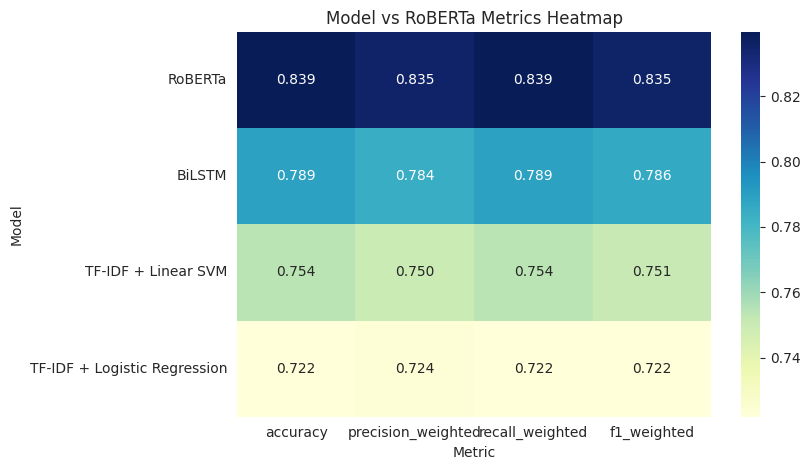

Saved: /content/drive/MyDrive/Emotional Aware Chatbot/experiments/goemotions_roberta_full_pipeline/reports/model_comparison/roberta_comparison/all_models_metric_barplot.png
Saved: /content/goemotions_roberta_full_pipeline/reports/model_comparison/roberta_comparison/all_models_metric_barplot.png


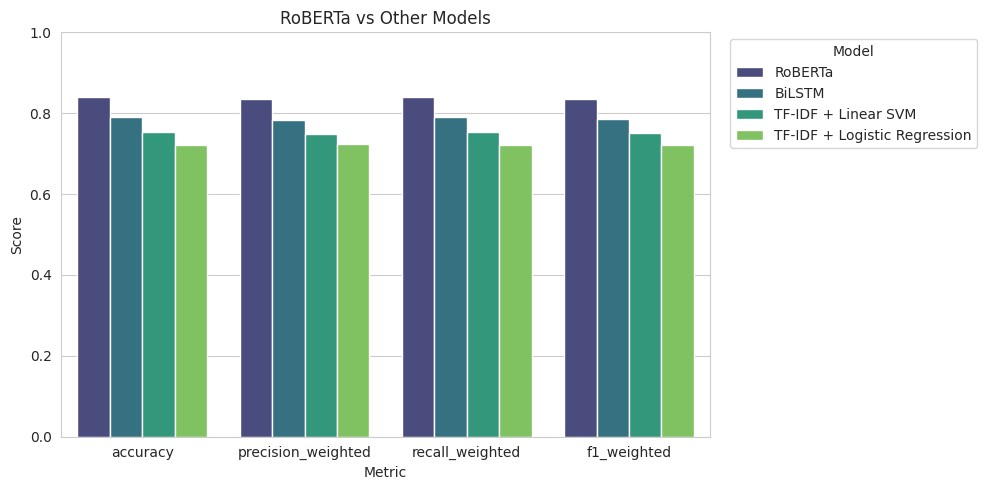

Saved: /content/drive/MyDrive/Emotional Aware Chatbot/experiments/goemotions_roberta_full_pipeline/reports/model_comparison/roberta_comparison/per_class_f1_heatmap.png
Saved: /content/goemotions_roberta_full_pipeline/reports/model_comparison/roberta_comparison/per_class_f1_heatmap.png


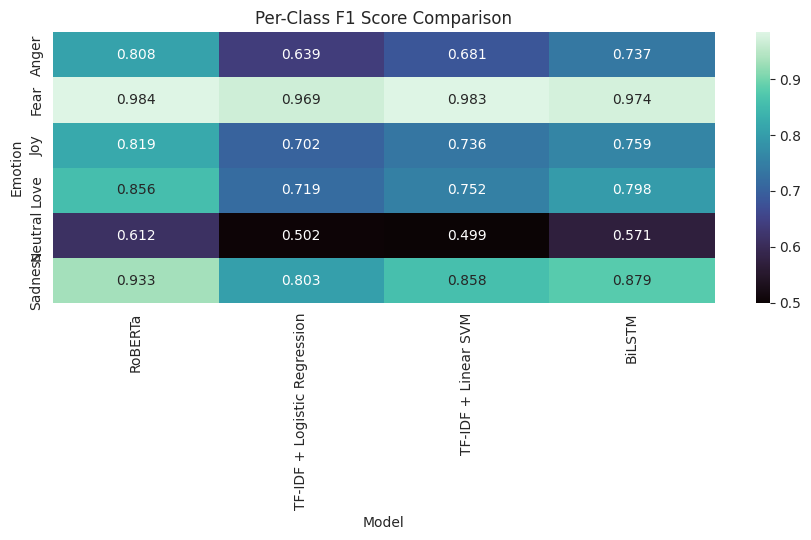

Saved: /content/drive/MyDrive/Emotional Aware Chatbot/experiments/goemotions_roberta_full_pipeline/reports/model_comparison/roberta_comparison/per_class_f1_delta_vs_roberta.png
Saved: /content/goemotions_roberta_full_pipeline/reports/model_comparison/roberta_comparison/per_class_f1_delta_vs_roberta.png


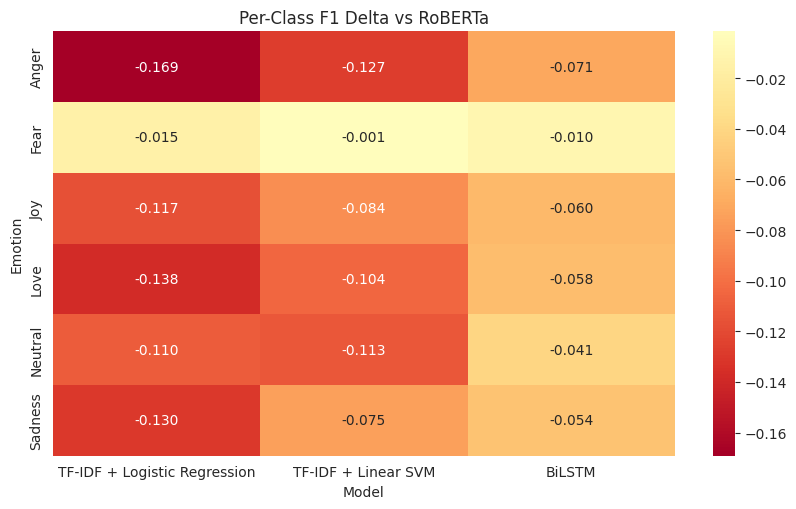

Saved: /content/drive/MyDrive/Emotional Aware Chatbot/experiments/goemotions_roberta_full_pipeline/reports/model_comparison/roberta_comparison/normalized_confusion_matrix_grid.png
Saved: /content/goemotions_roberta_full_pipeline/reports/model_comparison/roberta_comparison/normalized_confusion_matrix_grid.png


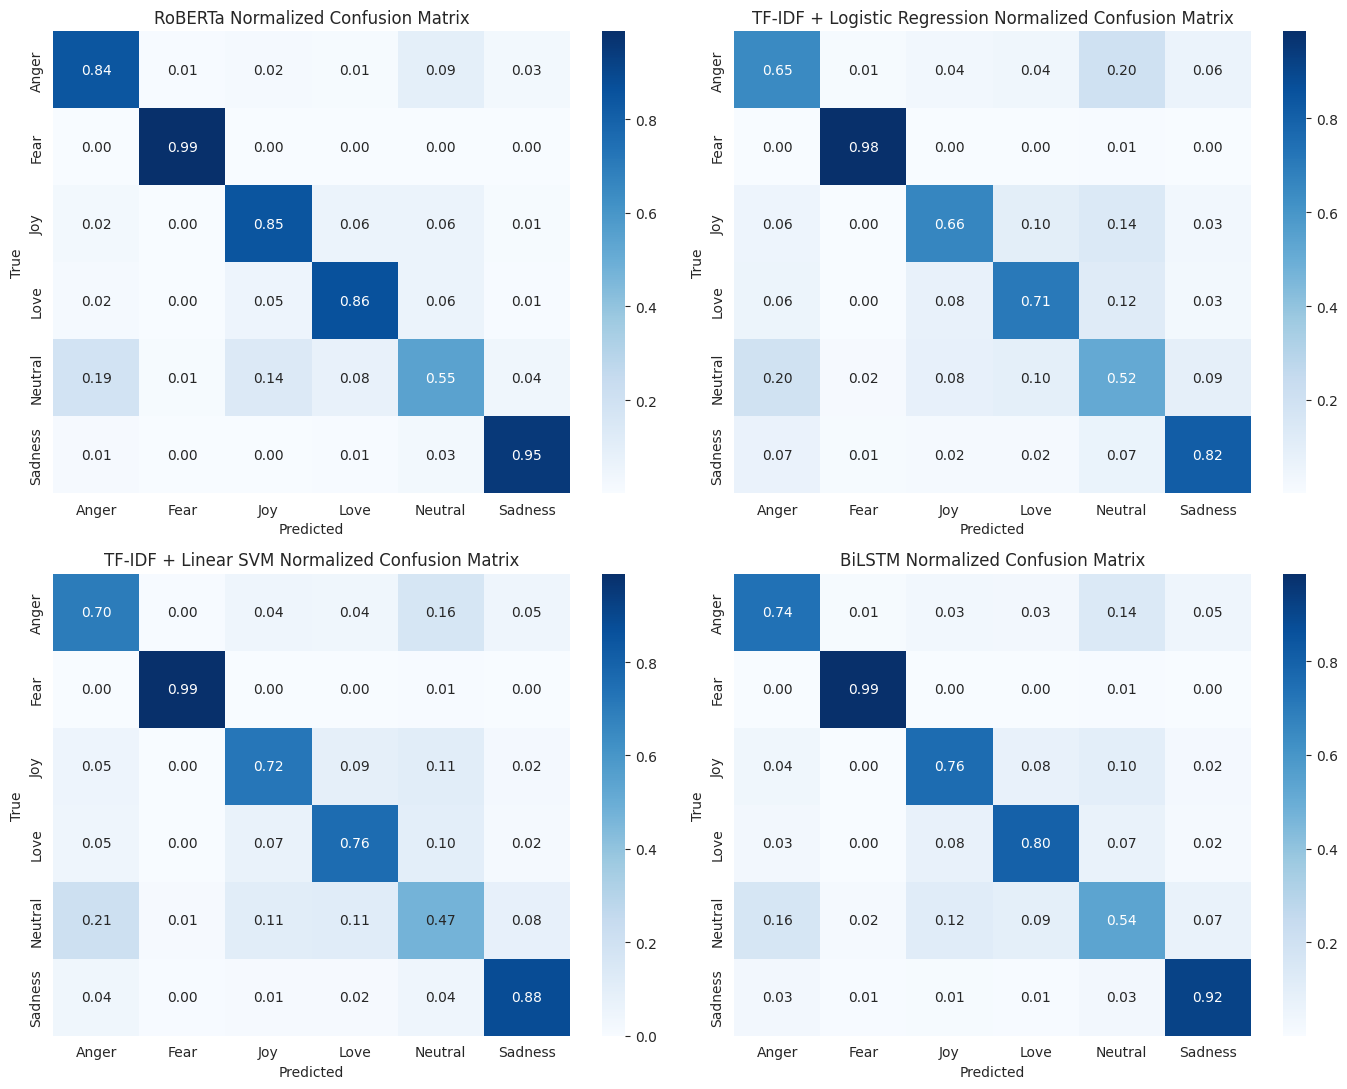

Comparison artifacts saved to: /content/drive/MyDrive/Emotional Aware Chatbot/experiments/goemotions_roberta_full_pipeline/reports/model_comparison/roberta_comparison
Local comparison artifacts saved to: /content/goemotions_roberta_full_pipeline/reports/model_comparison/roberta_comparison


In [18]:
# Compare TF-IDF/BiLSTM models against the main RoBERTa pipeline and save all comparison visuals
import json
from pathlib import Path

COMPARE_DIR = REPORT_DIR / 'roberta_comparison'
COMPARE_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_COMPARE_DIR = None
if 'LOCAL_PROJECT_ROOT' in globals() and LOCAL_PROJECT_ROOT is not None:
    LOCAL_COMPARE_DIR = LOCAL_PROJECT_ROOT / 'reports' / 'model_comparison' / 'roberta_comparison'
    LOCAL_COMPARE_DIR.mkdir(parents=True, exist_ok=True)

ROBERTA_REPORT_DIR = PROJECT_ROOT / 'reports'
roberta_metrics_path = ROBERTA_REPORT_DIR / 'metrics.json'
roberta_report_path = ROBERTA_REPORT_DIR / 'classification_report.csv'
roberta_cm_path = ROBERTA_REPORT_DIR / 'confusion_matrix.csv'

for required_path in [roberta_metrics_path, roberta_report_path, roberta_cm_path]:
    if not required_path.exists():
        raise FileNotFoundError(f'Missing RoBERTa artifact: {required_path}')

with open(roberta_metrics_path) as f:
    roberta_metrics = json.load(f)

roberta_row = {
    'model': 'RoBERTa',
    'accuracy': roberta_metrics['accuracy'],
    'precision_weighted': roberta_metrics['precision_weighted'],
    'recall_weighted': roberta_metrics['recall_weighted'],
    'f1_weighted': roberta_metrics['f1_weighted'],
}

comparison_df = pd.concat([
    pd.DataFrame([roberta_row]),
    results_df[['model', 'accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']].copy(),
], ignore_index=True).sort_values('f1_weighted', ascending=False).reset_index(drop=True)
display(comparison_df)

def save_dataframe_both(df, drive_path: Path):
    df.to_csv(drive_path, index=True if df.index.name or df.index.dtype == 'object' else False)
    print('Saved:', drive_path)
    if LOCAL_COMPARE_DIR is not None:
        local_path = LOCAL_COMPARE_DIR / drive_path.name
        df.to_csv(local_path, index=True if df.index.name or df.index.dtype == 'object' else False)
        print('Saved:', local_path)

def save_figure_both(fig, drive_path: Path):
    fig.savefig(drive_path, dpi=220, bbox_inches='tight')
    print('Saved:', drive_path)
    if LOCAL_COMPARE_DIR is not None:
        local_path = LOCAL_COMPARE_DIR / drive_path.name
        fig.savefig(local_path, dpi=220, bbox_inches='tight')
        print('Saved:', local_path)

metrics_heatmap = comparison_df.set_index('model')[['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']]
fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.heatmap(metrics_heatmap, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax)
ax.set_title('Model vs RoBERTa Metrics Heatmap')
ax.set_xlabel('Metric')
ax.set_ylabel('Model')
plt.tight_layout()
save_figure_both(fig, COMPARE_DIR / 'all_models_metrics_heatmap.png')
plt.show()
plt.close(fig)

metrics_long = comparison_df.melt(id_vars='model', var_name='metric', value_name='score')
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=metrics_long, x='metric', y='score', hue='model', palette='viridis', ax=ax)
ax.set_title('RoBERTa vs Other Models')
ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
save_figure_both(fig, COMPARE_DIR / 'all_models_metric_barplot.png')
plt.show()
plt.close(fig)

roberta_report_df = pd.read_csv(roberta_report_path, index_col=0)
per_class_f1 = {'RoBERTa': roberta_report_df.loc[label_names, 'f1-score']}
for model_name, report_dict in detailed_reports.items():
    per_class_f1[model_name] = pd.Series({label: report_dict[label]['f1-score'] for label in label_names})
per_class_f1_df = pd.DataFrame(per_class_f1).reindex(label_names)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(per_class_f1_df, annot=True, fmt='.3f', cmap='mako', ax=ax)
ax.set_title('Per-Class F1 Score Comparison')
ax.set_xlabel('Model')
ax.set_ylabel('Emotion')
plt.tight_layout()
save_figure_both(fig, COMPARE_DIR / 'per_class_f1_heatmap.png')
plt.show()
plt.close(fig)

roberta_delta_df = per_class_f1_df.sub(per_class_f1_df['RoBERTa'], axis=0).drop(columns='RoBERTa')
fig, ax = plt.subplots(figsize=(8.5, 5.2))
sns.heatmap(roberta_delta_df, annot=True, fmt='+.3f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Per-Class F1 Delta vs RoBERTa')
ax.set_xlabel('Model')
ax.set_ylabel('Emotion')
plt.tight_layout()
save_figure_both(fig, COMPARE_DIR / 'per_class_f1_delta_vs_roberta.png')
plt.show()
plt.close(fig)

model_cm_map = {
    'RoBERTa': pd.read_csv(roberta_cm_path, index_col=0).loc[label_names, label_names].to_numpy(),
    'TF-IDF + Logistic Regression': confusion_matrix(y_test, lr_pred, labels=label_names),
    'TF-IDF + Linear SVM': confusion_matrix(y_test, svm_pred, labels=label_names),
    'BiLSTM': confusion_matrix(y_test, bilstm_pred, labels=label_names),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, (model_name, cm) in zip(axes.flatten(), model_cm_map.items()):
    row_totals = cm.sum(axis=1, keepdims=True)
    row_totals[row_totals == 0] = 1
    cm_norm = cm / row_totals
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_title(f'{model_name} Normalized Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
save_figure_both(fig, COMPARE_DIR / 'normalized_confusion_matrix_grid.png')
plt.show()
plt.close(fig)

comparison_df.to_csv(COMPARE_DIR / 'all_models_vs_roberta_metrics.csv', index=False)
per_class_f1_df.to_csv(COMPARE_DIR / 'per_class_f1_scores.csv')
roberta_delta_df.to_csv(COMPARE_DIR / 'per_class_f1_delta_vs_roberta.csv')

if LOCAL_COMPARE_DIR is not None:
    comparison_df.to_csv(LOCAL_COMPARE_DIR / 'all_models_vs_roberta_metrics.csv', index=False)
    per_class_f1_df.to_csv(LOCAL_COMPARE_DIR / 'per_class_f1_scores.csv')
    roberta_delta_df.to_csv(LOCAL_COMPARE_DIR / 'per_class_f1_delta_vs_roberta.csv')

print('Comparison artifacts saved to:', COMPARE_DIR)
if LOCAL_COMPARE_DIR is not None:
    print('Local comparison artifacts saved to:', LOCAL_COMPARE_DIR)


## Notes for Report

- Use `model_comparison_results.csv` in your final report table.
- Use the confusion matrices to discuss class-wise strengths and weaknesses.
- Compare this notebook's best model with your RoBERTa results from notebook 03.